In [1]:
import pandas as pd
df = pd.read_csv('HistoricalData.csv')
display(df.head())

,Year,S&P 500 (includes dividends),US Small cap (bottom decile),3-month T.Bill,US T. Bond (10-year),Baa Corporate Bond,Real Estate,Gold*,Inflation
0,1928,43.81%,59.91%,3.08%,0.84%,3.22%,1.49%,0.10%,-1.16
1,1929,-8.30%,-46.61%,3.16%,4.20%,3.02%,-2.06%,-0.15%,0.58
2,1930,-25.12%,-50.03%,4.55%,4.54%,0.54%,-4.30%,0.10%,-6.40
3,1931,-43.84%,-44.66%,2.31%,-2.56%,-15.68%,-8.15%,-17.38%,-9.32
4,1932,-8.64%,20.49%,1.07%,8.79%,23.59%,-10.47%,21.28%,-10.27


In [4]:
# Make a copy to avoid modifying the original DataFrame directly if it's used elsewhere
df_cleaned = df.copy()

# Identify columns that are strings and contain '%'
cols_to_clean = []
for col in df_cleaned.columns:
    # Check if the column is of object type (string) and if any value contains '%'
    # .astype(str) is used to handle potential mixed types or non-string objects to avoid errors
    if df_cleaned[col].dtype == 'object' and df_cleaned[col].astype(str).str.contains('%', na=False).any():
        cols_to_clean.append(col)

print(f"Columns identified for cleaning (removing '%' and converting to float): {cols_to_clean}")

for col in cols_to_clean:
    # Remove '%' and convert to float, then divide by 100 to get decimal values
    df_cleaned[col] = df_cleaned[col].astype(str).str.replace('%', '', regex=False).astype(float) / 100

# Inflation is in percentage values and must be scaled to decimals
if 'Inflation' in df_cleaned.columns:
    df_cleaned['Inflation'] = pd.to_numeric(df_cleaned['Inflation'], errors='coerce') / 100

    # Display the cleaned DataFrame's head to show changes
display(df_cleaned.head())

Columns identified for cleaning (removing '%' and converting to float): ['S&P 500 (includes dividends)', 'US Small cap (bottom decile)', '3-month T.Bill', 'US T. Bond (10-year)', ' Baa Corporate Bond', 'Real Estate', 'Gold*']


,Year,S&P 500 (includes dividends),US Small cap (bottom decile),3-month T.Bill,US T. Bond (10-year),Baa Corporate Bond,Real Estate,Gold*,Inflation
0,1928,0.4381,0.5991,0.0308,0.0084,0.0322,0.0149,0.0010,-0.0116
1,1929,-0.0830,-0.4661,0.0316,0.0420,0.0302,-0.0206,-0.0015,0.0058
2,1930,-0.2512,-0.5003,0.0455,0.0454,0.0054,-0.0430,0.0010,-0.0640
3,1931,-0.4384,-0.4466,0.0231,-0.0256,-0.1568,-0.0815,-0.1738,-0.0932
4,1932,-0.0864,0.2049,0.0107,0.0879,0.2359,-0.1047,0.2128,-0.1027


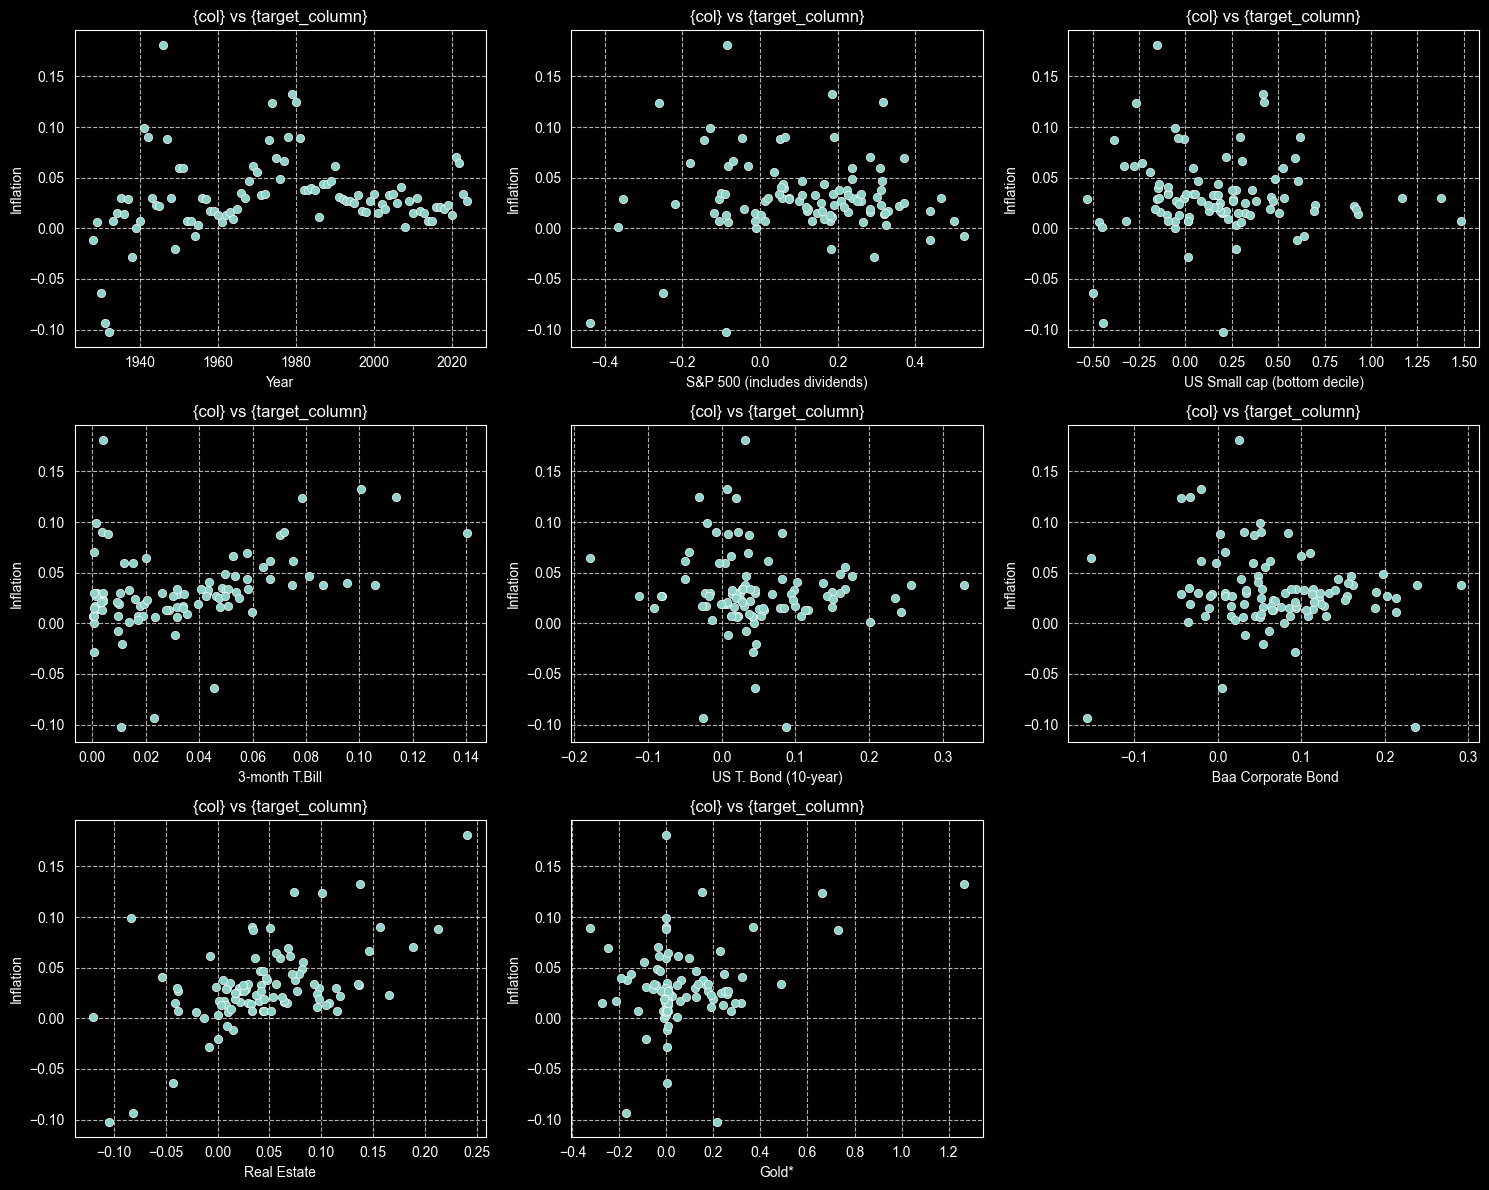

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

target_column = 'Inflation'

# Check if 'Inflation' column exists in the cleaned DataFrame
if target_column not in df_cleaned.columns:
    print(
        f"Error: The column '{target_column}' was not found in the DataFrame. Please ensure the data contains an 'Inflation' column for plotting.")
else:
    # Ensure 'Inflation' is numeric, attempting conversion if not.
    if not pd.api.types.is_numeric_dtype(df_cleaned[target_column]):
        print(f"Warning: The column '{target_column}' is not numeric. Attempting to convert.")
        try:
            df_cleaned[target_column] = df_cleaned[target_column].astype(str).str.replace('%', '', regex=False).astype(
                float) / 100
        except ValueError:
            print(
                f"Error: Could not convert '{target_column}' to a numeric type. Please check its values and rerun. Skipping plotting.")
            target_column = None  # Set to None to prevent plotting

    if target_column:  # Proceed only if target_column is valid and numeric
        numeric_columns = df_cleaned.select_dtypes(include=['float64', 'int64']).columns.tolist()

        if target_column in numeric_columns:
            numeric_columns.remove(target_column)  # Remove target from features list for plotting against itself

        if not numeric_columns:
            print("No other numeric columns available for plotting against Inflation after cleaning.")
        else:
            num_plots = len(numeric_columns)
            # Determine grid size for subplots
            n_cols = 3  # You can adjust this for desired grid width
            n_rows = (num_plots + n_cols - 1) // n_cols  # Calculate number of rows needed

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
            axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

            for i, col in enumerate(numeric_columns):
                sns.scatterplot(x=df_cleaned[col], y=df_cleaned[target_column], ax=axes[i])
                axes[i].set_title(f'{{col}} vs {{target_column}}')
                axes[i].set_xlabel(col)
                axes[i].set_ylabel(target_column)
                axes[i].grid(True, linestyle='--', alpha=0.7)

            # Hide any unused subplots if the number of plots doesn't fill the grid
            for j in range(i + 1, len(axes)):  # i is the index of the last plot
                fig.delaxes(axes[j])

            plt.tight_layout()
            plt.show()


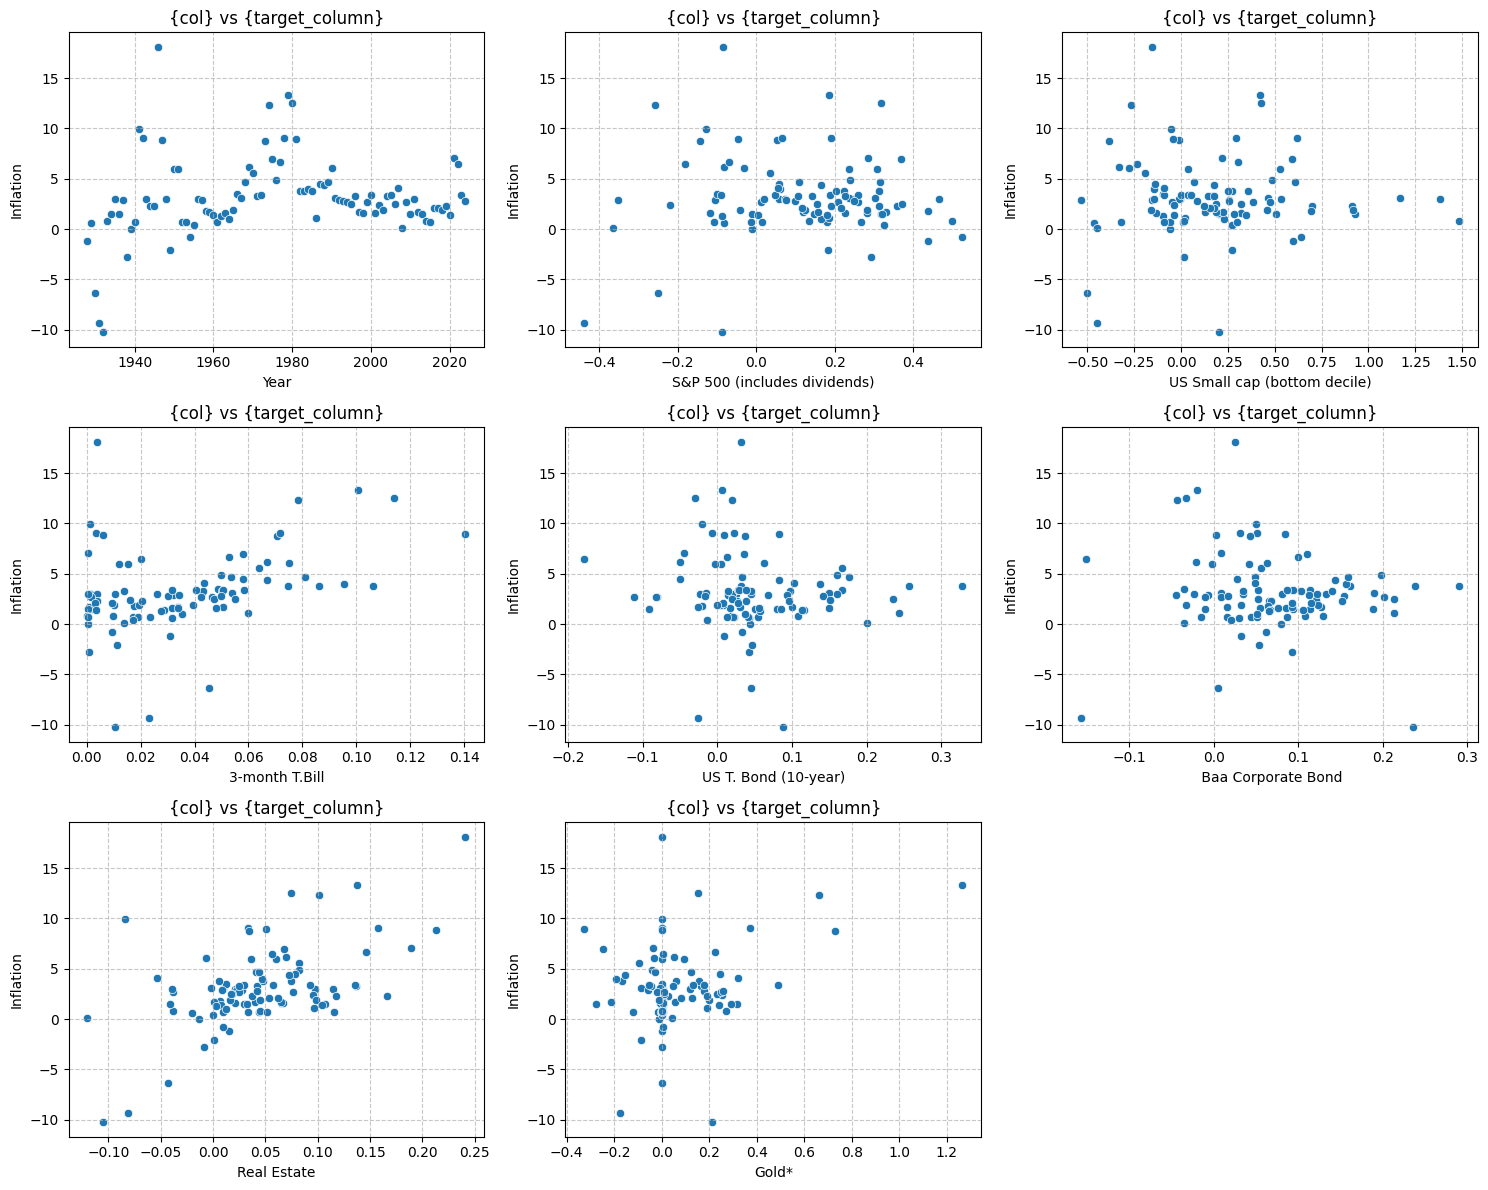